In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import numpy as np

from nexuskan import *
from nexuskan import KAN
from nexuskan import nexusKAN

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# grad test

$x_1 x_3 + x_2 x_5 + x_4$

in: 5, out: 2

In [4]:
def some_func_to_add_dim(x, out_dim):
    x_res = torch.unsqueeze(x, dim=2)
    for i in range(out_dim - 1):
        x_res = torch.concat((x_res, torch.unsqueeze(x * 2., dim=2)), dim=2)
    
    return x_res

In [ ]:
batch = 4
in_dim = 5
out_dim = 2

y_true = torch.tensor([[ -6., -28.],
                       [-21., -79.],
                       [36.,  138.],
                       [11.,  42.]]) # (batch, out_dim)
criterion = nn.MSELoss()

mask = torch.tensor([[0.9, -0.5], 
                     [-0.6, 0.6], 
                     [0.8, -0.5], 
                     [-0.9, -0.6],
                     [-0.6, 0.8]]).requires_grad_(True) # (in_dim, in_dim // 2)

x = torch.tensor([[2.0, 2.0, -2.0, 2.0, -2.0],
                  [3.0, -3.0, -3.0, -3.0, 3.0],
                  [4.0, -4.0, 4.0, 4.0, -4.0],
                  [4.0, -1.0, 2.0, 1.0, -2.0]]).requires_grad_(True) # (batch, in_dim)

y = some_func_to_add_dim(x, out_dim=out_dim) # (batch, in_dim, out_dim)

tau = 0.1
hard_mask = torch.sigmoid(mask / tau) # (in_dim, in_dim // 2)

# --- signs with threshold ---
# epsilon = 1e-8
# sign_data = torch.sign(y + epsilon) # (batch, in_dim, out_dim)
# mask_expanded = hard_mask[None, :, None, :] # (1, in_dim, 1, groups)
# sign_data_expanded = sign_data.unsqueeze(-1) # (batch, in_dim, out_dim, 1)
# selected_signs = torch.where(mask_expanded > 0.5, sign_data_expanded, 1.0) # (batch, in_dim, out_dim, in_dim // 2)
# final_sign = torch.prod(selected_signs, dim=1) # (batch, out_dim, in_dim // 2)
# masked_y_for_prod = torch.pow(torch.abs(y.unsqueeze(-1)), hard_mask[None, :, None, :]) # (batch, in_dim, out_dim, in_dim // 2)

# --- signs with linear representation ---
masked_y_for_prod = 1 - hard_mask[None, :, None, :] + hard_mask[None, :, None, :] * y.unsqueeze(-1) # (batch, in_dim, out_dim, in_dim // 2)
y_prod = torch.prod(masked_y_for_prod, dim=1) # (batch, out_dim, in_dim // 2)

masked_y_for_sum = y * (1. - torch.sum(hard_mask, dim=1)[:, None]) # (batch, in_dim, out_dim)

y = torch.sum(masked_y_for_sum, dim=1) + torch.sum(y_prod, dim=2)

print("y.size() =", y.size())
print(y)
loss = criterion(y, y_true)
loss.backward()
print(mask.grad)



y.size() = torch.Size([4, 2])
tensor([[ -6., -28.],
        [-21., -78.],
        [ 36., 136.],
        [ 11.,  42.]], grad_fn=<AddBackward0>)
tensor([[-0.0000e+00, -5.1401e-18],
        [ 3.0516e-22, -0.0000e+00],
        [-0.0000e+00, -2.9992e-18],
        [-0.0000e+00, -1.3616e-22],
        [ 2.0797e-22, -0.0000e+00]])


# **Dataset** $y = x_0 x_2 +  x_4 \sin{2 \pi x_3} + x_2$ and 2 learnable prod group

In [134]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 5) + start_range
# y = torch.sin(2 * torch.pi * x[:, 0]) + torch.sin(2 * torch.pi * x[:, 1])
y = x[:, 0] * x[:, 2] + torch.sin(2 * torch.pi * x[:, 3]) * x[:, 4] + x[:, 1]
# y = x[:, 0] * x[:, 2] + x[:, 1]
# y_class = torch.where(y > 0.5, 1.0, 0.0)
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    # 'train_label': y_class[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
    # 'test_label': y_class[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 5]), torch.Size([1000, 1]))

checkpoint directory created: ./model
saving model version 0.0


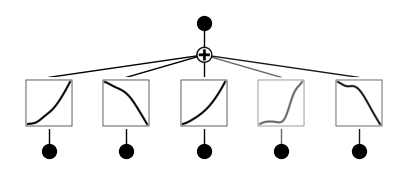

In [135]:
model = nexusKAN(width=[5, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [136]:
optimizer = optim.Adam(model.parameters(), lr=0.1)

In [137]:
def get_tau(step, total_steps, tau_start=2.0, tau_end=0.01):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

In [138]:
criterion = nn.MSELoss()

batch_size = 512 # dataset['train_input'].shape[0]
epochs = 1000

grid_update_freq = 200

for epoch in range(epochs):
    batches = dataset['train_input'].shape[0] // batch_size
    for batch_idx in range(batches):
        if batch_idx == batches - 1:
            indices = torch.arange(batch_idx * batch_size, dataset['train_input'].shape[0])
        else:
            indices = torch.arange(batch_idx * batch_size, (batch_idx + 1) * batch_size)
        
        batch_x = dataset['train_input'][indices]
        batch_y = dataset['train_label'][indices]
        
        if epoch % grid_update_freq == 0:
            model.update_grid(batch_x)
        # if (epoch + 1) % grid_update_freq == 0:
        #     for param_group in optimizer.param_groups:
        #         param_group['lr'] *= 0.8
                
        new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
        for module in model.modules():
            if isinstance(module, NexusKANLayer):
                module.tau = new_tau

        
        outputs = model(batch_x)
        
        train_loss = criterion(outputs, batch_y)
        
        lamb = 0.00001
        l1_reg = sum(torch.norm(p, 1) for p in model.parameters())
        loss = train_loss + lamb * l1_reg
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        test_outputs = model(dataset['test_input'])
        test_loss = criterion(test_outputs, dataset['test_label'])
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}, reg: {l1_reg:.4f}')

Epoch [10/1000], Train Loss: 0.3251, Test Loss: 0.3587, reg: 110.7804
Epoch [20/1000], Train Loss: 0.2820, Test Loss: 0.3436, reg: 120.2808
Epoch [30/1000], Train Loss: 0.2771, Test Loss: 0.3496, reg: 121.9176
Epoch [40/1000], Train Loss: 0.2726, Test Loss: 0.3449, reg: 125.8305
Epoch [50/1000], Train Loss: 0.2701, Test Loss: 0.3467, reg: 126.8032
Epoch [60/1000], Train Loss: 0.2692, Test Loss: 0.3439, reg: 128.6769
Epoch [70/1000], Train Loss: 0.2687, Test Loss: 0.3457, reg: 129.5705
Epoch [80/1000], Train Loss: 0.2682, Test Loss: 0.3464, reg: 130.5724
Epoch [90/1000], Train Loss: 0.2677, Test Loss: 0.3482, reg: 131.3883
Epoch [100/1000], Train Loss: 0.2672, Test Loss: 0.3491, reg: 132.4456
Epoch [110/1000], Train Loss: 0.2662, Test Loss: 0.3493, reg: 134.1014
Epoch [120/1000], Train Loss: 0.2466, Test Loss: 0.2941, reg: 138.5072
Epoch [130/1000], Train Loss: 0.1868, Test Loss: 0.1986, reg: 140.2038
Epoch [140/1000], Train Loss: 0.1673, Test Loss: 0.1671, reg: 143.3669
Epoch [150/1000

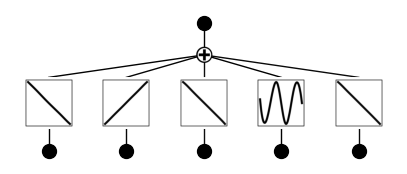

In [139]:
model.plot()

In [80]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[-2.3980e-03, -2.2230e-02,  1.4831e-01,  1.9897e-01,  2.1028e-01,
           1.3970e-01, -4.7181e-03, -1.6971e-03]],

        [[-1.0941e-04,  1.3223e-01,  3.6816e-01,  4.9737e-01,  6.0058e-01,
           6.0465e-01,  6.8389e-01,  1.6910e-01]],

        [[ 2.1204e-03, -2.0766e-02,  1.2759e-01,  1.8951e-01,  1.8691e-01,
           1.2805e-01, -9.8595e-03,  6.1817e-04]],

        [[-7.6700e-01,  1.1928e+00,  1.8744e+00,  4.5978e-01, -1.3612e+00,
          -1.5002e+00,  2.8754e-01,  1.6308e+00]],

        [[ 9.7536e-04, -3.7089e-02, -8.5080e-02, -1.0406e-01, -9.5239e-02,
          -6.6383e-02,  2.1766e-04,  5.8613e-03]]], device='cuda:0')
act_fun.0.scale_base tensor([[ 1.3415],
        [ 1.1233],
        [ 1.3433],
        [-0.5591],
        [ 0.4912]], device='cuda:0')
act_fun.0.scale_sp tensor([[ 0.2722],
        [ 0.2917],
        [ 0.2999],
        [ 1.8345],
        [-0.2740]], device='cuda:0')
act_fun.0.logits tensor([[ 3.0311e-04,  1.0255e+00,  6.9879e-01],
 

# **Dataset** $y = $ 

In [150]:
end_range = 1.0
start_range = 0.2
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 8) + start_range

y = (x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]) / (x[:, 4] / x[:, 5] + x[:, 6] / x[:, 7])

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    # 'train_label': y_class[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
    # 'test_label': y_class[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 8]), torch.Size([1000, 1]))

checkpoint directory created: ./model
saving model version 0.0


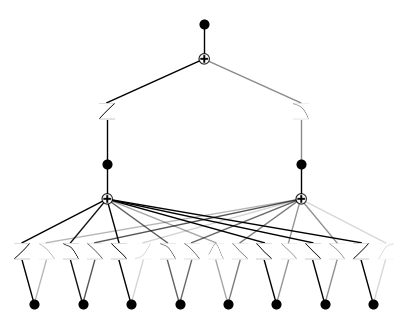

In [151]:
model = nexusKAN(width=[8, 2, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [152]:
optimizer = optim.Adam(model.parameters(), lr=0.1)

In [153]:
def get_tau(step, total_steps, tau_start=2.0, tau_end=0.1):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

In [154]:
criterion = nn.MSELoss()

batch_size = 512 # dataset['train_input'].shape[0]
epochs = 1000

grid_update_freq = 200

for epoch in range(epochs):
    batches = dataset['train_input'].shape[0] // batch_size
    for batch_idx in range(batches):
        if batch_idx == batches - 1:
            indices = torch.arange(batch_idx * batch_size, dataset['train_input'].shape[0])
        else:
            indices = torch.arange(batch_idx * batch_size, (batch_idx + 1) * batch_size)
        
        batch_x = dataset['train_input'][indices]
        batch_y = dataset['train_label'][indices]
        
        # if epoch % grid_update_freq == 0:
        #     model.update_grid(batch_x)
        if (epoch + 1) % grid_update_freq == 0:
            for param_group in optimizer.param_groups:
                param_group['lr'] *= 0.8
                
        new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
        for module in model.modules():
            if isinstance(module, NexusKANLayer):
                module.tau = new_tau

        
        outputs = model(batch_x)
        
        train_loss = criterion(outputs, batch_y)
        
        lamb = 0.000001
        l1_reg = sum(torch.norm(p, 1) for p in model.parameters())
        loss = train_loss + lamb * l1_reg
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        test_outputs = model(dataset['test_input'])
        test_loss = criterion(test_outputs, dataset['test_label'])
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}, reg: {l1_reg:.4f}')

Epoch [10/1000], Train Loss: 0.7344, Test Loss: 0.6150, reg: 235.3000
Epoch [20/1000], Train Loss: 0.1879, Test Loss: 0.1722, reg: 284.8313
Epoch [30/1000], Train Loss: 0.0870, Test Loss: 0.0841, reg: 292.8423
Epoch [40/1000], Train Loss: 0.0550, Test Loss: 0.0633, reg: 297.2436
Epoch [50/1000], Train Loss: 0.0405, Test Loss: 0.0549, reg: 298.6942
Epoch [60/1000], Train Loss: 0.0371, Test Loss: 0.0527, reg: 302.2084
Epoch [70/1000], Train Loss: 0.0351, Test Loss: 0.0463, reg: 306.3466
Epoch [80/1000], Train Loss: 0.0331, Test Loss: 0.0425, reg: 310.3493
Epoch [90/1000], Train Loss: 0.0314, Test Loss: 0.0405, reg: 315.3391
Epoch [100/1000], Train Loss: 0.0294, Test Loss: 0.0382, reg: 320.3906
Epoch [110/1000], Train Loss: 0.0266, Test Loss: 0.0351, reg: 327.0625
Epoch [120/1000], Train Loss: 0.0227, Test Loss: 0.0303, reg: 334.3495
Epoch [130/1000], Train Loss: 0.0186, Test Loss: 0.0256, reg: 341.9881
Epoch [140/1000], Train Loss: 0.0149, Test Loss: 0.0207, reg: 347.4256
Epoch [150/1000

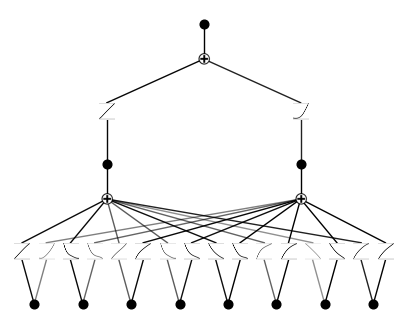

In [155]:
model.plot()

In [156]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[-2.7964e-03, -5.4692e-03,  2.1060e-03, -2.1588e+00, -9.9237e-01,
           4.6766e-01,  1.6458e+00,  2.0790e+00],
         [ 2.0367e-03,  1.1283e-02, -1.1349e-03, -5.0742e-01, -9.1650e-01,
          -4.8035e-01,  1.7919e-01,  1.3714e+00]],

        [[-1.1901e-02,  9.3162e-03, -1.5282e-03,  9.7002e+00,  7.4539e-01,
           1.3984e-01, -5.0449e-01,  1.4990e-01],
         [ 9.1982e-03,  3.2393e-03, -7.0156e-04,  2.8248e+00, -3.2669e-01,
          -5.6238e-01,  6.1142e-02, -3.5818e-01]],

        [[ 5.6706e-03,  7.1379e-04, -4.5814e-03, -1.6864e+00, -1.9301e-03,
           6.9643e-01,  1.1866e+00,  2.5016e+00],
         [ 9.9346e-05,  2.9852e-03, -8.8135e-03, -4.0364e+00, -1.0110e+00,
          -1.5961e-01,  4.7421e-01,  9.4595e-01]],

        [[-5.9839e-03, -8.4866e-03,  4.2538e-04,  6.0487e+00,  9.7329e-01,
           4.8227e-01, -4.4871e-02,  4.9179e-01],
         [-2.0209e-03,  6.4658e-03, -7.5594e-04,  4.4594e+00,  3.3269e-01,
          -2.8240e-01, -1.397